**Time forecasting**

Data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

from prophet import Prophet

# ============================================================
# 1) CARICAMENTO DATI
# ============================================================

df = pd.read_csv(r"C:\Users\maria\Desktop\esami polito\progettiCV\data analyst\Sample - Superstore.csv\Sample - Superstore.csv", parse_dates=["Order Date"], encoding="latin1") #insert the adress for the file .csv in the first part of the command

# Resampling mensile
ts = df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"].sum()
ts = ts.asfreq("ME")

print(ts.head())

Importing plotly failed. Interactive plots will not work.


Order Date
2014-01-31    14236.895
2014-02-28     4519.892
2014-03-31    55691.009
2014-04-30    28295.345
2014-05-31    23648.287
Freq: ME, Name: Sales, dtype: float64


Series visualization

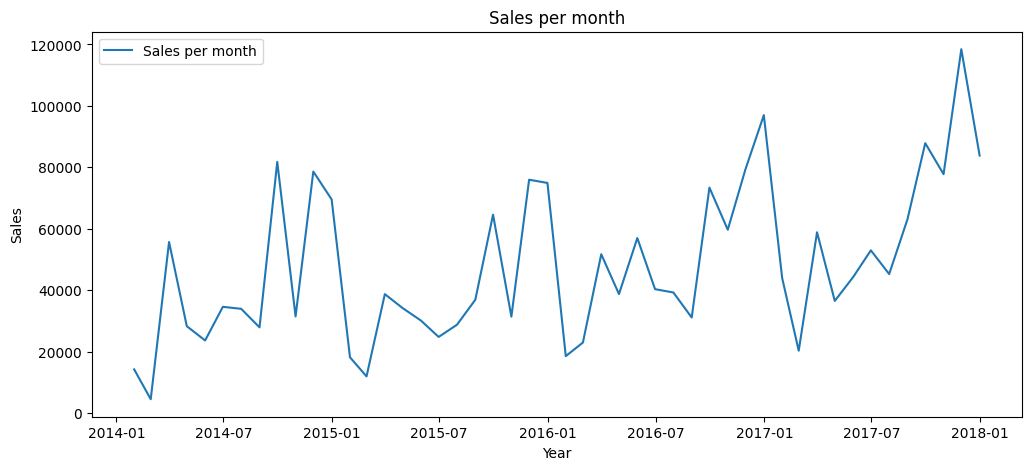

In [3]:
plt.figure(figsize=(12,5))
plt.plot(ts, label="Sales per month")
plt.title("Sales per month")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.legend()
plt.show()

STL decomposition

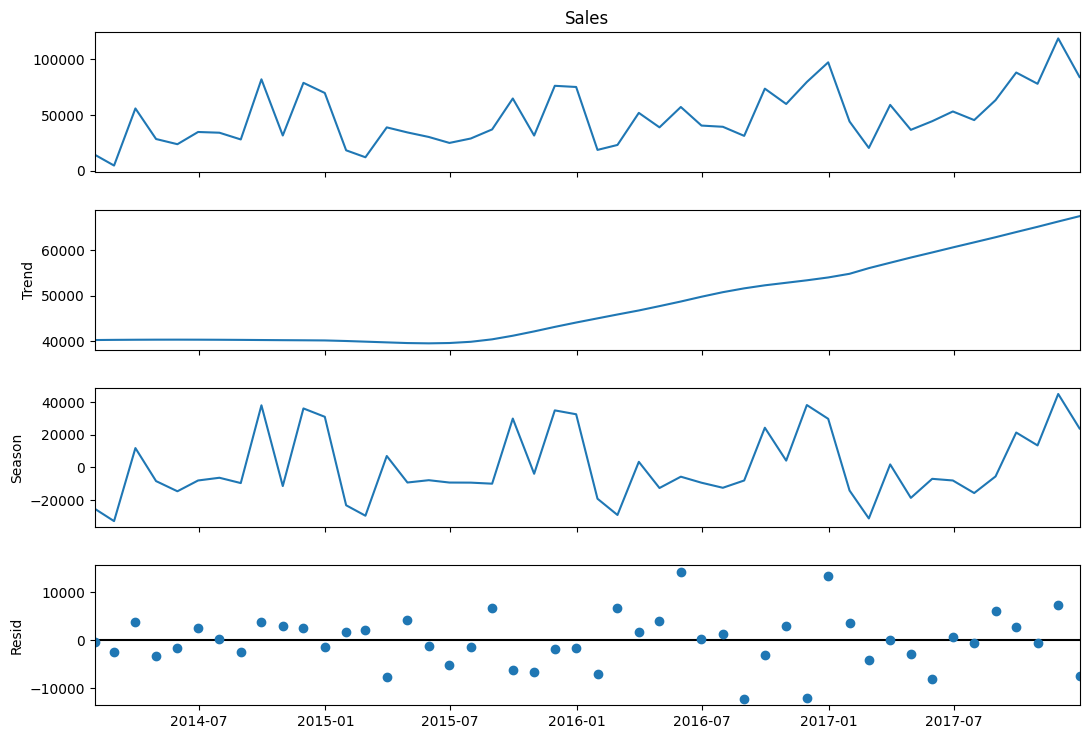

In [4]:
stl = STL(ts, period=12)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(12,8)
plt.show()

ACF/PACF

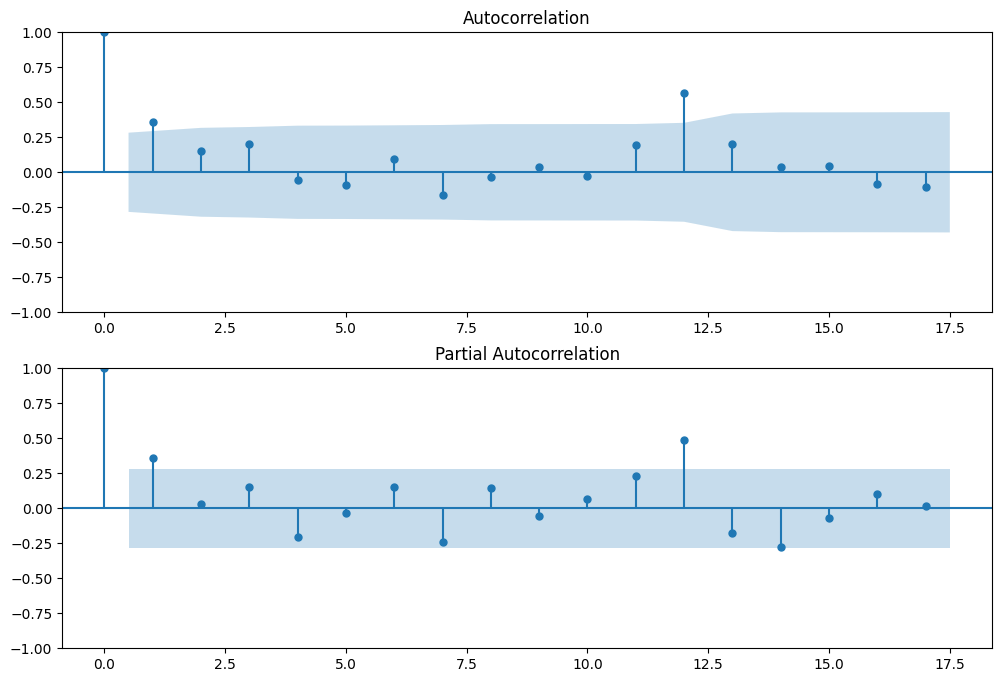

In [5]:
fig, ax = plt.subplots(2,1, figsize=(12,8))
plot_acf(ts.dropna(), ax=ax[0])
plot_pacf(ts.dropna(), ax=ax[1])
plt.show()

ARIMA model

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -401.805
Date:                Thu, 27 Aug 2026   AIC                            809.610
Time:                        18:41:02   BIC                            814.276
Sample:                    01-31-2014   HQIC                           811.220
                         - 12-31-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1072      0.281      0.382      0.703      -0.443       0.658
ma.L1         -0.7533      0.168     -4.492      0.000      -1.082      -0.425
sigma2      5.705e+08    1.2e-10   4.74e+18      0.0

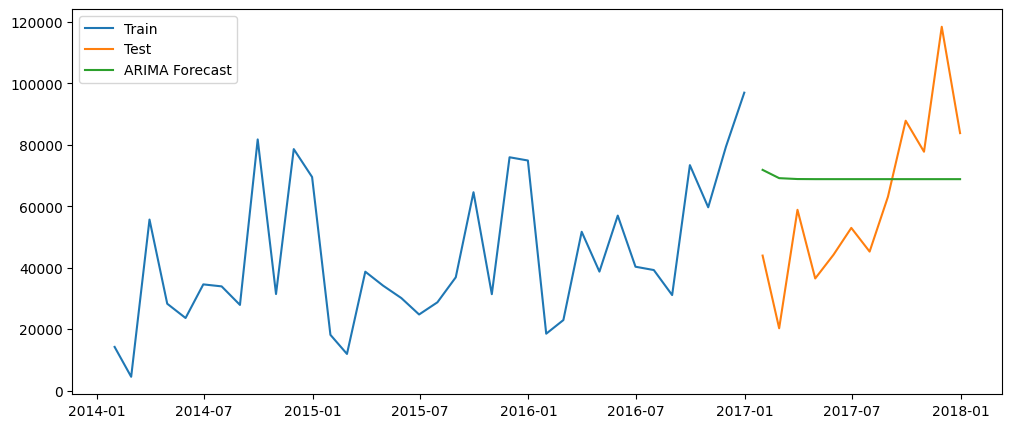

In [6]:
# Split train/test
train = ts[:-12]
test = ts[-12:]

model = ARIMA(train, order=(1,1,1))
arima_fit = model.fit()

print(arima_fit.summary())

# Forecast ARIMA
arima_forecast = arima_fit.forecast(steps=12)

# Metriche ARIMA
mae_arima = mean_absolute_error(test, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test, arima_forecast))

print("MAE ARIMA:", mae_arima)
print("RMSE ARIMA:", rmse_arima)

# Plot ARIMA
plt.figure(figsize=(12,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(arima_forecast, label="ARIMA Forecast")
plt.legend()
plt.show()

Prophet Model

18:41:06 - cmdstanpy - INFO - Chain [1] start processing
18:41:06 - cmdstanpy - INFO - Chain [1] done processing


MAE Prophet: 11648.917406343762
RMSE Prophet: 15252.542082975817


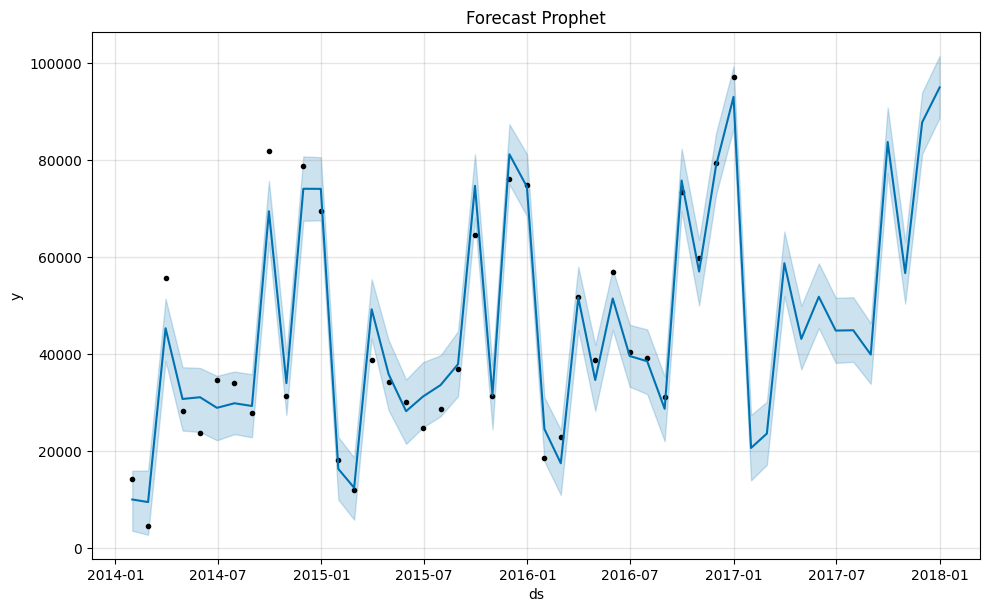

In [7]:
prophet_df = ts.reset_index()
prophet_df.columns = ["ds", "y"]

# Train/test split
train_prophet = prophet_df[:-12]
test_prophet = prophet_df[-12:]

m = Prophet()
m.fit(train_prophet)

future = m.make_future_dataframe(periods=12, freq="ME")
forecast = m.predict(future)

# Metriche Prophet
prophet_pred = forecast["yhat"][-12:].values

mae_prophet = mean_absolute_error(test_prophet["y"], prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(test_prophet["y"], prophet_pred))

print("MAE Prophet:", mae_prophet)
print("RMSE Prophet:", rmse_prophet)

# Plot Prophet
m.plot(forecast)
plt.title("Forecast Prophet")
plt.show()

Model comparison and best model

In [9]:


print("====================================")
print("MODEL COMPARISON")
print("ARIMA - MAE:", mae_arima, "RMSE:", rmse_arima)
print("Prophet - MAE:", mae_prophet, "RMSE:", rmse_prophet)
print("====================================")



if rmse_prophet < rmse_arima:
    print("The best model is: PROPHET")
else:
    print("The best model is: ARIMA")

MODEL COMPARISON
ARIMA - MAE: 23450.62727311719 RMSE: 27208.447462697644
Prophet - MAE: 11648.917406343762 RMSE: 15252.542082975817
The best model is: PROPHET
